# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler # Important for LSTM
import matplotlib.pyplot as plt

# Loading and Filtering Data

In [2]:
df = pd.read_csv("stock_details_5_years.csv")

# Filter one company
df = df[df['Company'] == 'AAPL']

# Sort by date
df = df.sort_values('Date')

df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.0,0.0,AAPL
458,2018-11-30 00:00:00-05:00,43.261071,43.270671,42.478826,42.850754,158126000,0.0,0.0,AAPL
916,2018-12-03 00:00:00-05:00,44.261681,44.376858,43.481835,44.348064,163210000,0.0,0.0,AAPL
1374,2018-12-04 00:00:00-05:00,43.419445,43.764977,42.296468,42.397247,165377200,0.0,0.0,AAPL
1832,2018-12-06 00:00:00-05:00,41.214280,41.938938,40.892744,41.924541,172393600,0.0,0.0,AAPL


# Using multiple features

In [3]:
data = df[['Open', 'High', 'Low', 'Close', 'Volume']].values
data[:5]

array([[4.38297606e+01, 4.38633538e+01, 4.26395936e+01, 4.30835075e+01,
        1.67080000e+08],
       [4.32610709e+01, 4.32706710e+01, 4.24788264e+01, 4.28507538e+01,
        1.58126000e+08],
       [4.42616813e+01, 4.43768576e+01, 4.34818349e+01, 4.43480644e+01,
        1.63210000e+08],
       [4.34194446e+01, 4.37649771e+01, 4.22964676e+01, 4.23972473e+01,
        1.65377200e+08],
       [4.12142798e+01, 4.19389381e+01, 4.08927440e+01, 4.19245415e+01,
        1.72393600e+08]])

# Train Test Split

In [4]:
train_size = int(len(data) * 0.8)

train_data = data[:train_size]
test_data = data[train_size:]

print(train_data.shape, test_data.shape)

(1006, 5) (252, 5)


# Normalising the Data

In [5]:
scaler = MinMaxScaler()

train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

print(train_data[:2])

[[0.06356299 0.06098006 0.05989454 0.06147106 0.33702874]
 [0.05966835 0.05691802 0.05877047 0.05987505 0.31414687]]


# Creating Sequences

In [6]:
def create_sequences(data, seq_length):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][3])  # 3 = Close column

    return np.array(X), np.array(y)

seq_length = 60

X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

print(X_train.shape, X_test.shape)

(946, 60, 5) (192, 60, 5)


# Conversion to Pytorch Tensors

In [7]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train.shape, y_train.shape)

torch.Size([946, 60, 5]) torch.Size([946, 1])


# Building LSTM Model

In [8]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=5,
            hidden_size=100,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(100, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last time step
        out = self.fc(out)
        return out

# Initializing model, loss, optimizer

In [9]:
model = LSTMModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


# Training Loop

In [10]:
epochs = 80
batch_size = 32

for epoch in range(epochs):
    model.train()

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        output = model(X_batch)
        loss = criterion(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.007875067181885242
Epoch 2, Loss: 0.05919796973466873
Epoch 3, Loss: 0.011872169561684132
Epoch 4, Loss: 0.006858266890048981
Epoch 5, Loss: 0.0016353708924725652
Epoch 6, Loss: 0.0019926074892282486
Epoch 7, Loss: 0.00167204556055367
Epoch 8, Loss: 0.001586596597917378
Epoch 9, Loss: 0.0015232989098876715
Epoch 10, Loss: 0.001476991456001997
Epoch 11, Loss: 0.0014482229016721249
Epoch 12, Loss: 0.0014335042797029018
Epoch 13, Loss: 0.0014287467347458005
Epoch 14, Loss: 0.0014291135594248772
Epoch 15, Loss: 0.0014313324354588985
Epoch 16, Loss: 0.0014356167521327734
Epoch 17, Loss: 0.0014466233551502228
Epoch 18, Loss: 0.0014754767762497067
Epoch 19, Loss: 0.0015471501974388957
Epoch 20, Loss: 0.0017212999518960714
Epoch 21, Loss: 0.0021396824158728123
Epoch 22, Loss: 0.003055460285395384
Epoch 23, Loss: 0.004799780435860157
Epoch 24, Loss: 0.01629236713051796
Epoch 25, Loss: 0.019964275881648064
Epoch 26, Loss: 0.01179650891572237
Epoch 27, Loss: 0.005513353273272514


# Predictions

In [11]:
model.eval()

with torch.no_grad():
    predictions = model(X_test)

print(predictions[:5])

tensor([[0.7946],
        [0.7972],
        [0.7960],
        [0.7897],
        [0.7845]])


# Conversion To Original Price Values

In [12]:
# Convert tensors to numpy
predictions = predictions.numpy()
y_test = y_test.numpy()

# Create dummy arrays (same number of features = 5)
pred_dummy = np.zeros((len(predictions), 5))
y_dummy = np.zeros((len(y_test), 5))

# Put predicted Close price in correct column (index 3)
pred_dummy[:, 3] = predictions.flatten()
y_dummy[:, 3] = y_test.flatten()

# Inverse transform
predictions = scaler.inverse_transform(pred_dummy)[:, 3]
y_test_actual = scaler.inverse_transform(y_dummy)[:, 3]

print(predictions[:5])

[149.99531281 150.37534651 150.20218431 149.27857724 148.52875823]


# Plotting Actual vs Predicted

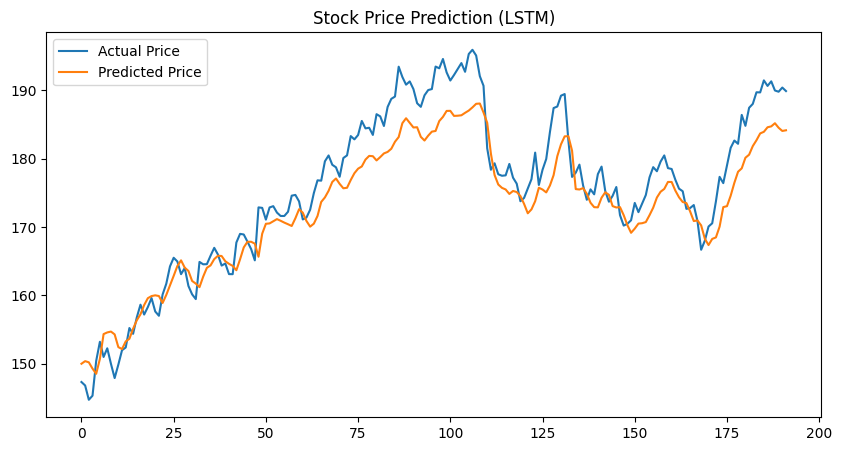

In [13]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.legend()
plt.title("Stock Price Prediction (LSTM)")
plt.show()

# RMSE

In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

RMSE: 4.333378685671892


# Built a multi-feature LSTM model using PyTorch to predict stock prices from OHLCV data, achieving an RMSE of 4.33 and accurately capturing temporal trends in financial time-series data.